### import utils

In [1]:
import warnings
import pandas as pd
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

from a_utils import (
    keep_rows_with_any_filled,
    keep_positives,
    get_sym_severity,
    get_symptom_severity_score,
    add_boolean_combo_features,
    is_abnormal_cxr,
    open_data,
    plot_fill_rates,
    build_model,
    compute_feature_importance,
    plot_feature_importance,
    plot_importance_vs_fill_rate,
    compute_shap_importance,
    plot_shap_importance,
    plot_shap_summary,
    compute_column_outcome_correlation,
    plot_outcome_correlation,
    log_column_names_with_single_unique_value,
    SYMPTOMS,
    VITALS,
    CXR_FIELDS,
    LABEL,
    LABEL_VALUES,
    logging
)

c:\Users\somry\Projects\covidclinicaldata\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### load data

In [2]:
data = open_data()
log_column_names_with_single_unique_value(data)


### plot fill rates

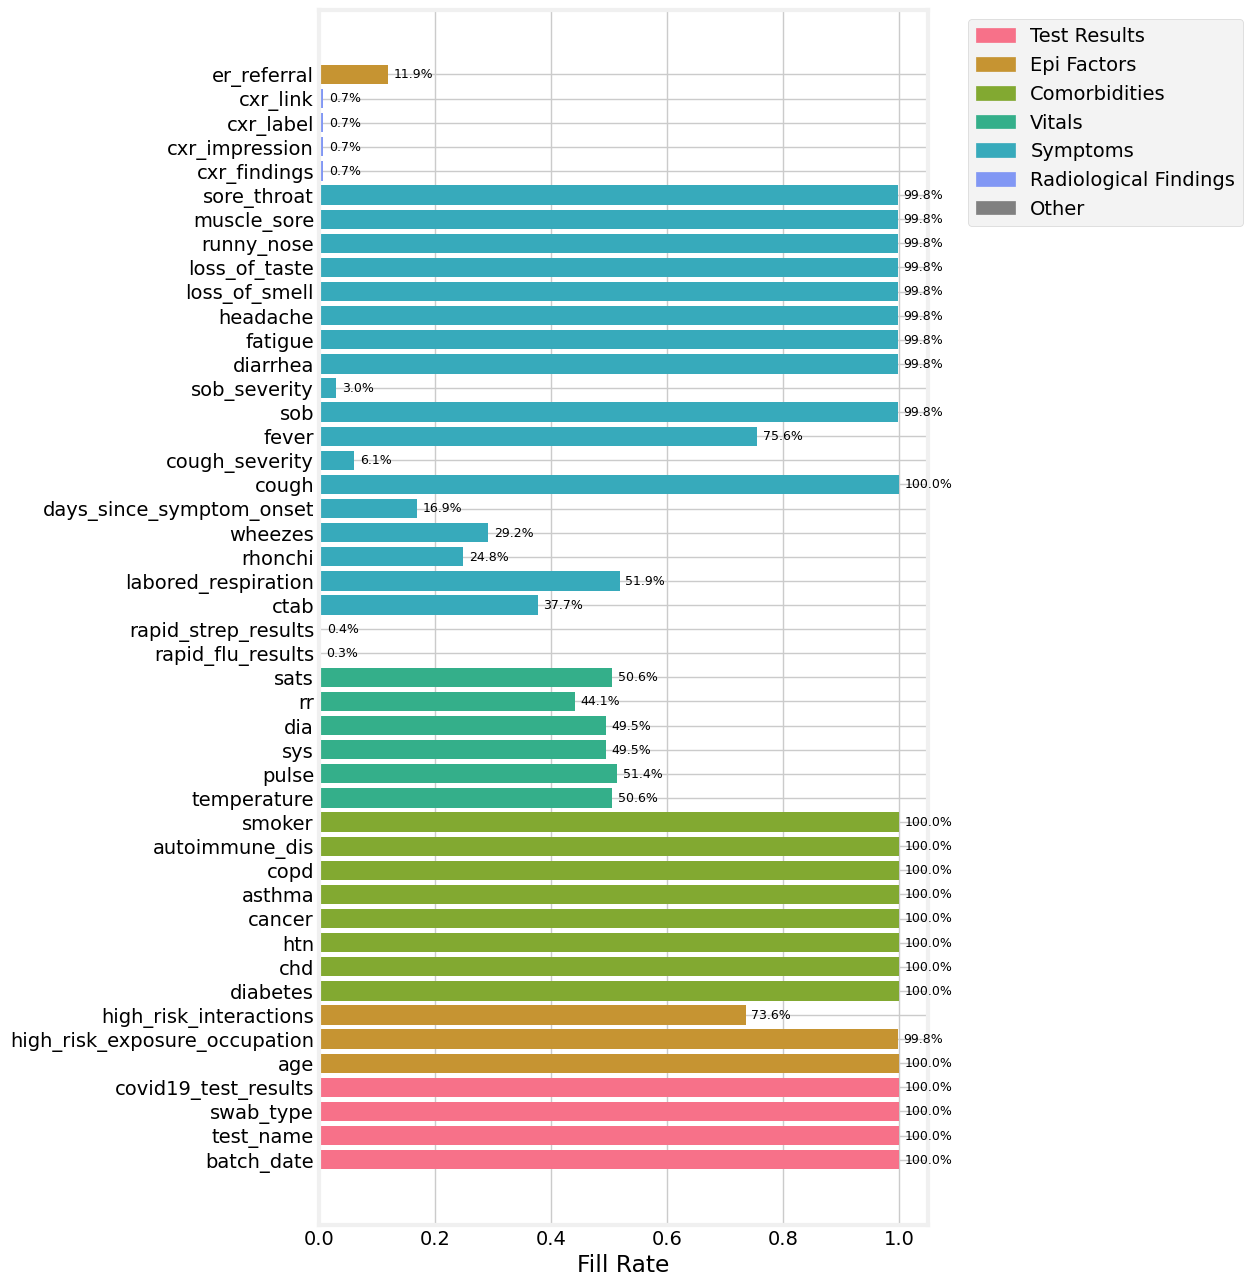

In [3]:
plot_fill_rates(data)


### process and filter data

In [3]:
positive_patients = keep_positives(data)
symptomatic_patients = keep_rows_with_any_filled(data, SYMPTOMS)
patients_with_vitals = keep_rows_with_any_filled(data, VITALS, col_type='numeric')

# see Appendix A for details on the CXR fields and the reason we drop them.
data = data.drop(columns=CXR_FIELDS, errors='ignore')

# see Appendix B for details on the rapid results fields and the reason we drop them.
data = data.drop(columns=["rapid_flu_results", "rapid_strep_results"], errors='ignore')

# Restrict the training cohort to rows where the patient was either symptomatic
# (any SYMPTOMS column True) or had any vital measured. The ~67k asymptomatic-
# and-no-vitals rows carry almost no informative features and drown the signal.
keep_mask = data[SYMPTOMS].eq(True).any(axis=1) | data[VITALS].notna().any(axis=1)
data = data[keep_mask].reset_index(drop=True)
logging.info(f'Training cohort: {len(data):,} rows after symptomatic-or-vitals filter')

# add a column for the number of symptoms, only for rows that have at least one symptom filled in
data['num_symptoms'] = data[SYMPTOMS].eq(True).sum(axis=1)

# add a column for the symptom severity score, only for rows that have at least one symptom filled in
data['severity_score'] = data.apply(get_symptom_severity_score, axis=1)
data['sym_severity'] = data.severity_score.apply(get_sym_severity)

# Boolean-combo engineered features derived from the symptom/risk booleans:
# - anosmia_or_ageusia / anosmia_and_ageusia: the two strongest discriminators, as OR and AND
# - constitutional_score: count of flu-like systemic symptoms (fever, muscle_sore, fatigue, headache)
# - competing_dx_auscultation: rhonchi|wheezes — composite of the strongest *negative* predictors
# - upper_resp_only: common-cold pattern (upper-resp symptoms without fever/anosmia/cough)
# - covid_specific_pattern: (smell|taste|fever) & cough — high-specificity COVID pattern
# - organ_system_diversity: number of distinct symptom domains involved (0–4)
add_boolean_combo_features(data)

INFO:root:Filtering out patients...


INFO:root:    ---- 93995 --> 26577 (28.27%)
INFO:root:Filtering out patients...
INFO:root:    ---- 93995 --> 49341 (52.49%)
INFO:root:Training cohort: 52,397 rows after symptomatic-or-vitals filter


In [8]:
def convert_column_types(df):
    """Convert object columns that hold only True/False/NaN to bool, and
    object columns whose values all parse as numbers to numeric."""
    bool_map = {"True": True, "False": False, True: True, False: False}
    for col in df.columns:
        if df[col].dtype != 'object':
            continue
        non_null = df[col].dropna()
        if non_null.empty:
            continue
        unique_vals = set(non_null.unique())
        if unique_vals.issubset({"True", "False", True, False}):
            df[col] = df[col].map(bool_map).astype('boolean')
            continue
        converted = pd.to_numeric(df[col], errors='coerce')
        if converted.notna().sum() == non_null.size:
            df[col] = converted
    return df

data = convert_column_types(data)

In [ ]:
for col, dtype in data.dtypes.items():
    print(f'{col}: {dtype}')

In [9]:
data.columns

Index(['batch_date', 'test_name', 'swab_type', 'covid19_test_results', 'age',
       'high_risk_exposure_occupation', 'high_risk_interactions', 'diabetes',
       'chd', 'htn', 'cancer', 'asthma', 'copd', 'autoimmune_dis', 'smoker',
       'temperature', 'pulse', 'sys', 'dia', 'rr', 'sats', 'ctab',
       'labored_respiration', 'rhonchi', 'wheezes', 'days_since_symptom_onset',
       'cough', 'cough_severity', 'fever', 'sob', 'sob_severity', 'diarrhea',
       'fatigue', 'headache', 'loss_of_smell', 'loss_of_taste', 'runny_nose',
       'muscle_sore', 'sore_throat', 'er_referral', 'num_symptoms',
       'severity_score', 'sym_severity'],
      dtype='str')

### feature importance analysis

In [5]:
classifier, X_train, y_train, X_val, y_val, X_test, y_test, fill_rates = build_model(data, n_trials=200)

INFO:root:Training xgboost on 52397 rows, 1200 positives (2.3%) — scale_pos_weight tunable up to 43
INFO:root:Train: 31437 (720 pos) | Val: 10480 (240 pos) | Test: 10480 (240 pos)
Best trial: 82. Best value: 0.170753:  50%|████▉     | 99/200 [32:52<33:32, 19.92s/it]  


[W 2026-05-12 01:10:35,633] Trial 99 failed with parameters: {'n_estimators': 770, 'max_depth': 4, 'learning_rate': 0.010807940777048063, 'subsample': 0.6829713476667574, 'colsample_bytree': 0.8246056671692213, 'min_child_weight': 1, 'reg_alpha': 0.010740521185028738, 'reg_lambda': 0.0016003208295741098, 'scale_pos_weight': 1.3980160980928733, 'gamma': 2.7603926135374524} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\somry\Projects\covidclinicaldata\venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "c:\Users\somry\Projects\covidclinicaldata\notebooks\a_utils.py", line 450, in objective
    scores = cross_val_score(
        Estimator(**params), X_train, y_train,
        cv=cv, scoring='average_precision', n_jobs=-1,
    )
  File "c:\Users\somry\Projects\covidclinicaldata\venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return fu

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score, precision_score,
    precision_recall_curve, average_precision_score,
)

# Pick the operating threshold on the VALIDATION set (no leakage), then report on TEST.
y_val_proba = classifier.predict_proba(X_val)[:, 1]
val_precisions, val_recalls, val_thresholds = precision_recall_curve(y_val, y_val_proba)
val_f1_curve = 2 * val_precisions[:-1] * val_recalls[:-1] / (val_precisions[:-1] + val_recalls[:-1] + 1e-9)
THRESHOLD = float(val_thresholds[val_f1_curve.argmax()])
logging.info(f'Threshold chosen on validation set (max-F1 on val): {THRESHOLD:.4f}')

y_proba = classifier.predict_proba(X_test)[:, 1]

# Precision/recall tradeoff across thresholds (test-set, reference only)
thresholds_to_check = sorted({0.05, 0.10, 0.20, 0.30, 0.50, THRESHOLD})
logging.info(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>8} {'N_pred_pos':>12}")
for t in thresholds_to_check:
    y_pred_t = (y_proba >= t).astype(int)
    logging.info(
        f"{t:>10.4f} "
        f"{precision_score(y_test, y_pred_t):>10.4f} "
        f"{recall_score(y_test, y_pred_t):>10.4f} "
        f"{f1_score(y_test, y_pred_t):>8.4f} "
        f"{y_pred_t.sum():>12}"
    )

y_pred = (y_proba >= THRESHOLD).astype(int)

logging.info('')
logging.info(f'--- Test metrics at validation-selected threshold={THRESHOLD:.4f} ---')
logging.info(f'Accuracy:              {accuracy_score(y_test, y_pred):.4f}')
logging.info(f'F1 score:              {f1_score(y_test, y_pred):.4f}')
logging.info(f'Precision (positives): {precision_score(y_test, y_pred):.4f}')
logging.info(f'Recall (positives):    {recall_score(y_test, y_pred, pos_label=1):.4f}')
logging.info(f'Recall (negatives):    {recall_score(y_test, y_pred, pos_label=0):.4f}')
logging.info(f'AUCPR (test):          {average_precision_score(y_test, y_proba):.4f}')

In [ ]:
importance_df = compute_feature_importance(classifier, X_train, fill_rates)
importance_df.head(10)

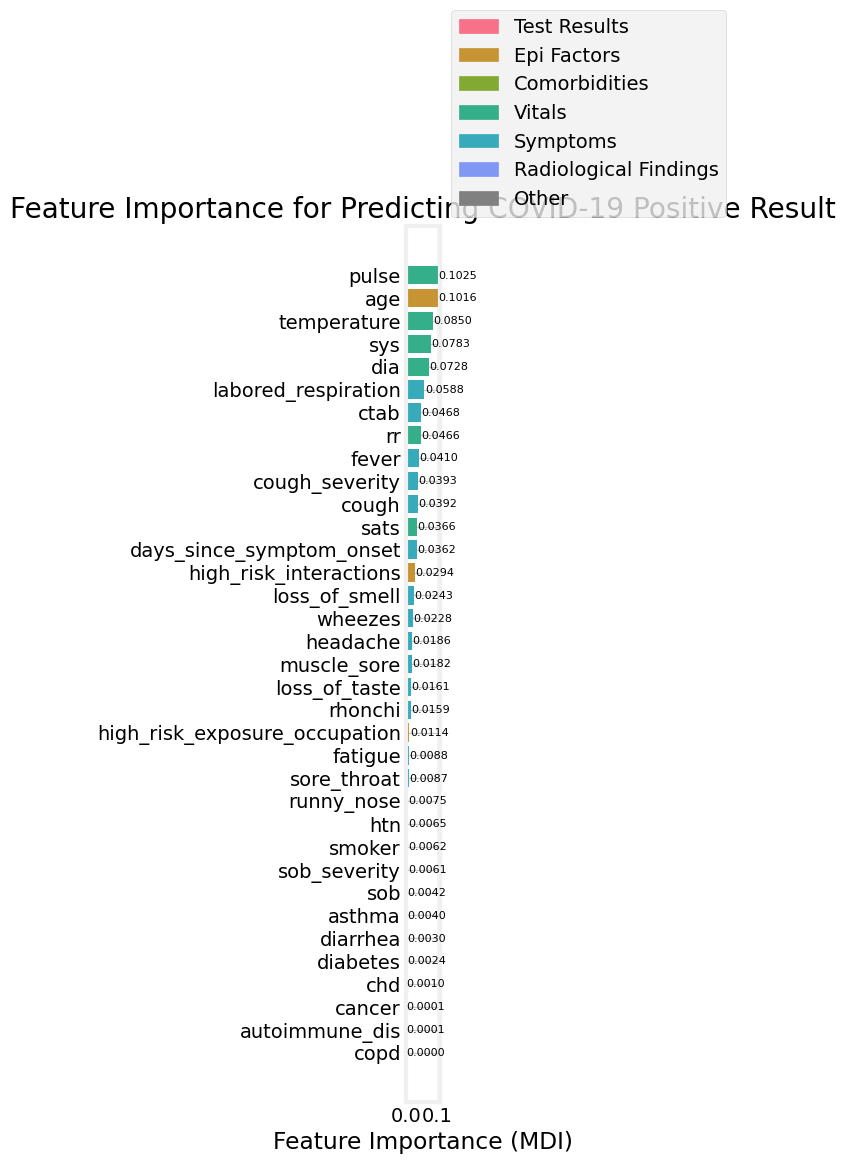

In [6]:
plot_feature_importance(importance_df)

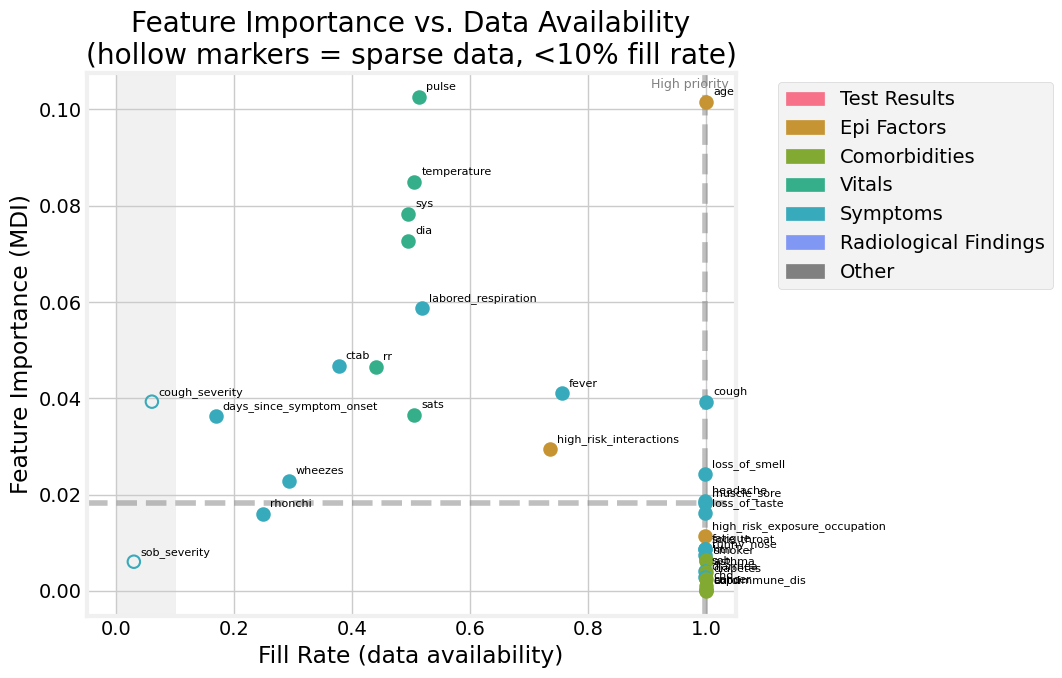

In [7]:
plot_importance_vs_fill_rate(importance_df)

### SHAP feature importance analysis

In [ ]:
shap_df, shap_values, X_shap = compute_shap_importance(classifier, X_train, y_train, fill_rates)
shap_df.head(10)

In [ ]:
plot_shap_importance(shap_df)

In [ ]:
plot_shap_summary(shap_values, X_shap)

In [ ]:
# Optional sanity baseline: re-train with LightGBM on the same data, using the same
# train/val/test split that build_model performs internally, and compare test F1.
# Skip by setting RUN_LGBM_BASELINE = False if you only want the XGBoost result.

RUN_LGBM_BASELINE = True

if RUN_LGBM_BASELINE:
    lgbm_clf, _, _, X_val_l, y_val_l, X_test_l, y_test_l, _ = build_model(
        data, n_trials=200, model_type='lightgbm'
    )

    # Pick threshold on validation, evaluate on test — same protocol as the XGB run.
    lgbm_val_proba = lgbm_clf.predict_proba(X_val_l)[:, 1]
    p_v, r_v, t_v = precision_recall_curve(y_val_l, lgbm_val_proba)
    f1_v = 2 * p_v[:-1] * r_v[:-1] / (p_v[:-1] + r_v[:-1] + 1e-9)
    lgbm_threshold = float(t_v[f1_v.argmax()])

    lgbm_test_proba = lgbm_clf.predict_proba(X_test_l)[:, 1]
    lgbm_pred = (lgbm_test_proba >= lgbm_threshold).astype(int)

    logging.info(
        f'LightGBM baseline — threshold={lgbm_threshold:.4f}, '
        f'test F1={f1_score(y_test_l, lgbm_pred):.4f}, '
        f'test AUCPR={average_precision_score(y_test_l, lgbm_test_proba):.4f}'
    )

### Appendix a: the reason to drop the CXR columns

The cxr columns have a very low fill rate (0.7%), and as you can see below, the correlation between positive and negative is pretty similar among them. Thus, I decided to drop them.

In [ ]:
has_cxr = ~data['cxr_impression'].isnull()

# add a column for whether the cxr impression is abnormal or not, only for rows that have a cxr impression
data.loc[has_cxr, 'is_abnormal_cxr'] = data.loc[
    has_cxr, 'cxr_impression'
].apply(is_abnormal_cxr)

In [ ]:
cxr_corr_df = compute_column_outcome_correlation(data, "is_abnormal_cxr")
cxr_corr_df

In [ ]:
plot_outcome_correlation(
    data,
    group_col=LABEL,
    rate_col='is_abnormal_cxr',
    group_values=LABEL_VALUES,
    rate_positive_value=True,
    ylabel='Patients with Abnormal CXR (%)',
    title='Abnormal CXR Rate by COVID-19 Outcome',
)

### Appendix B: Rapid Results Columns Outcome Correlation

For each rapid test column (`rapid_flu_results`, `rapid_strep_results`), we compute the COVID-19 positive rate among patients who tested positive vs. negative on the rapid test, along with the point-biserial correlation and p-value.

In [ ]:
data['rapid_flu_positive'] = data['rapid_flu_results'] == 'Positive'
flu_corr_df = compute_column_outcome_correlation(data, 'rapid_flu_positive')
flu_corr_df

In [ ]:
plot_outcome_correlation(
    data,
    group_col='rapid_flu_results',
    rate_col=LABEL,
    group_values=['Positive', 'Negative'],
    rate_positive_value='Positive',
    xlabel='rapid_flu_results Result',
    ylabel='COVID-19 Positive Rate (%)',
    title='rapid_flu_results: COVID-19 Positive Rate by Rapid Result',
)

In [ ]:
data['rapid_strep_positive'] = data['rapid_strep_results'] == 'Positive'
strep_corr_df = compute_column_outcome_correlation(data, 'rapid_strep_positive')
strep_corr_df

In [ ]:
plot_outcome_correlation(
    data,
    group_col='rapid_strep_results',
    rate_col=LABEL,
    group_values=['Positive', 'Negative'],
    rate_positive_value='Positive',
    xlabel='rapid_strep_results Result',
    ylabel='COVID-19 Positive Rate (%)',
    title='rapid_strep_results: COVID-19 Positive Rate by Rapid Result',
)

### Appendix C: general fields correlaions

In [19]:
# Set column width to None for no truncation
pd.set_option('display.max_colwidth', None)

In [42]:
negative_patients = data[data[LABEL] == "Negative"]

In [21]:
positive_patients.columns

Index(['batch_date', 'test_name', 'swab_type', 'covid19_test_results', 'age',
       'high_risk_exposure_occupation', 'high_risk_interactions', 'diabetes',
       'chd', 'htn', 'cancer', 'asthma', 'copd', 'autoimmune_dis', 'smoker',
       'temperature', 'pulse', 'sys', 'dia', 'rr', 'sats', 'rapid_flu_results',
       'rapid_strep_results', 'ctab', 'labored_respiration', 'rhonchi',
       'wheezes', 'days_since_symptom_onset', 'cough', 'cough_severity',
       'fever', 'sob', 'sob_severity', 'diarrhea', 'fatigue', 'headache',
       'loss_of_smell', 'loss_of_taste', 'runny_nose', 'muscle_sore',
       'sore_throat', 'cxr_findings', 'cxr_impression', 'cxr_label',
       'cxr_link', 'er_referral'],
      dtype='str')

In [90]:
data["er_referral"]

0        False
1        False
2        False
3        False
4        False
         ...  
52392      NaN
52393      NaN
52394      NaN
52395      NaN
52396      NaN
Name: er_referral, Length: 52397, dtype: object

<Axes: >

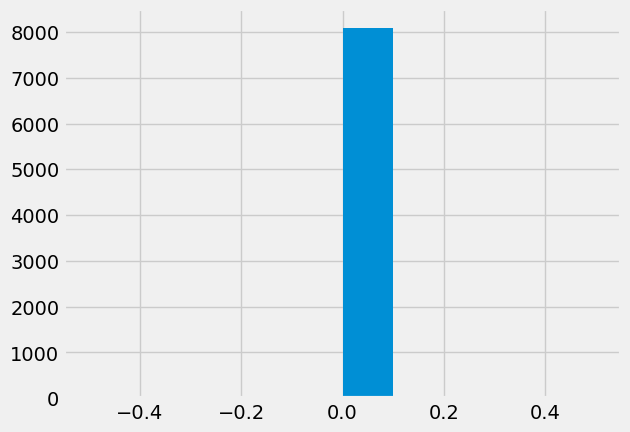

: 

In [ ]:
negative_patients["er_referral"].hist()

<Axes: >

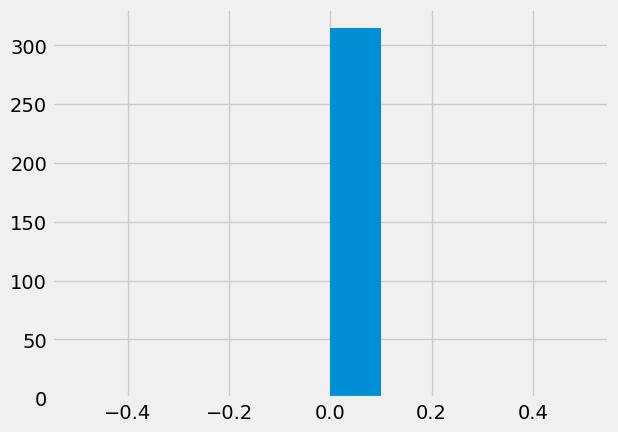

In [92]:
positive_patients["er_referral"].hist()

In [91]:
compute_column_outcome_correlation(data, "er_referral")

c:\Users\somry\Projects\covidclinicaldata\venv\Lib\site-packages\scipy\stats\_stats_py.py:5523: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
INFO:root:er_referral vs outcome: r=nan, p=nan, n=8,385


,outcome,n_total,n_true,pct_true,correlation,p_value
0,Negative,8091,0,0.0,NaN,NaN
1,Positive,294,0,0.0,NaN,NaN
